In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Q1

In [2]:
ds = pd.read_csv('Maternal Health Risk Data Set.csv')

In [3]:
ds.shape


(1014, 7)

In [4]:
ds.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [5]:
ds.tail()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
1009,22,120,60,15.0,98.0,80,high risk
1010,55,120,90,18.0,98.0,60,high risk
1011,35,85,60,19.0,98.0,86,high risk
1012,43,120,90,18.0,98.0,70,high risk
1013,32,120,65,6.0,101.0,76,mid risk


In [6]:
ds.info()

<class 'pandas.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   str    
dtypes: float64(2), int64(4), str(1)
memory usage: 55.6 KB


In [7]:
ds.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [33]:
from scipy import stats 
for i in numeric_col:
    print(i , round ( stats.kurtosis(ds[i]) , 2) )

Age -0.42
SystolicBP -0.62
DiastolicBP -0.95
BS 2.27
BodyTemp 1.46
HeartRate -0.49


In [8]:
ds.isnull().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

In [9]:
ds.duplicated().sum()

np.int64(562)

In [10]:
ds['RiskLevel'].value_counts()

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

In [11]:
ds['Age'].describe()

count    1014.000000
mean       29.871795
std        13.474386
min        10.000000
25%        19.000000
50%        26.000000
75%        39.000000
max        70.000000
Name: Age, dtype: float64

In [12]:
numeric_col = ['Age', 'SystolicBP',  'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']

for i in numeric_col:
    Q1 = ds[i].quantile(0.25)
    Q3 = ds[i].quantile(0.75)
    IQR = Q3-Q1
    lower_bound = Q1 - 1.5*Q1 
    upper_bound = Q3 + 1.5*Q3
    print(i, '|', upper_bound, '|', lower_bound)

Age | 97.5 | -9.5
SystolicBP | 300.0 | -50.0
DiastolicBP | 225.0 | -32.5
BS | 20.0 | -3.450000000000001
BodyTemp | 245.0 | -49.0
HeartRate | 200.0 | -35.0


In [13]:
import seaborn as sns

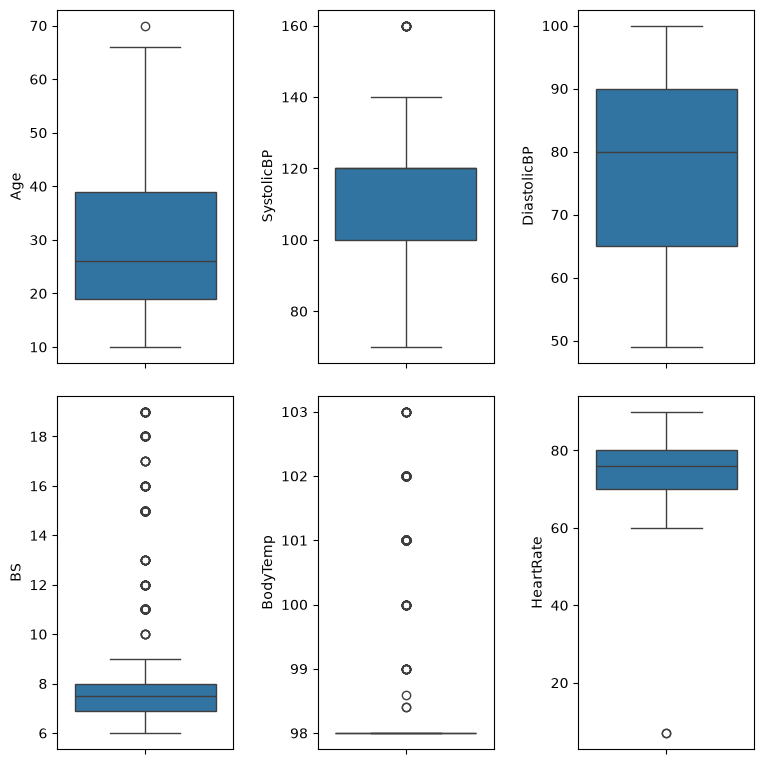

In [14]:
plt.figure(figsize=(8, 8))  
for index, i in enumerate(numeric_col):
    plt.subplot(2, 3, index+1)        
    sns.boxplot(ds[i])       
    
plt.tight_layout(pad=2)
plt.show()

Age 70 & HR 7 is already known as Error values i want to see these records and if there's not many remove it.

In [15]:
ds[ (ds['Age'] == 70) | (ds['HeartRate'] == 7) ]

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
338,70,85,60,6.9,102.0,70,low risk
499,16,120,75,7.9,98.0,7,low risk
908,16,120,75,7.9,98.0,7,low risk


i want to deleted these rec.s

why delete those records ?

Age 70 is physiologically implausible for pregnancy.

In [16]:
ds = ds.drop(index = [338,499,908])
ds.shape

(1011, 7)

3 records were removed based on physiological implausibility: 
- 1 record with age 70 (outside the realistic range of pregnancy) and 2 records with HeartRate=7 (incompatible with life). 
- This removal is independent of the issue of duplicates in the dataset; the other 560+ duplicate records that did not have implausible values ​​were retained.

Why don't I delete the rest of the duplicate rec.s? Because I think this ds was collected from India and Bangladesh, so this is not a far-fetched fact.

In [17]:
ds['RiskLevel'].value_counts()


RiskLevel
low risk     403
mid risk     336
high risk    272
Name: count, dtype: int64

In [18]:
round(403/272 , 2) # -> imbalance slow | middel

1.48

The RiskLevel express distribution is relatively balanced but not perfectly balanced (Low: 40%, Mid: 33%, High: 27%). This slight imbalance should be taken into account in the model evaluation (especially the Recall of the High Risk class).

In [25]:
lst = []
for i in numeric_col:
    lst.append(ds[i].nunique())

mult = 1 
for i in lst:
    mult *= i

print(ds.shape[0])
print(mult)

1011
51838080


In [ ]:
ds.value_counts()

Age  SystolicBP  DiastolicBP  BS    BodyTemp  HeartRate  RiskLevel
19   120         80           7.0   98.0      70         mid risk     27
48   120         80           11.0  98.0      88         high risk    14
31   120         60           6.1   98.0      76         mid risk     13
40   160         100          19.0  98.0      77         high risk    10
55   140         95           19.0  98.0      77         high risk    10
                                                                      ..
15   100         49           6.8   99.0      77         low risk      1
                              6.0   99.0      77         low risk      1
                 60           6.0   98.0      80         low risk      1
                 49           7.6   98.0      77         low risk      1
21   100         50           6.8   98.0      60         low risk      1
Name: count, Length: 450, dtype: int64

In [28]:
ds['BodyTemp'].value_counts()

BodyTemp
98.0     802
101.0     98
102.0     65
100.0     20
103.0     13
99.0      10
98.4       2
98.6       1
Name: count, dtype: int64

Similar to the BodyTemp assessment, other variables may also be affected by system default values; this is documented as a known limitation.


The dataset contains 1011 records and 7 columns after removing 3 implausible values:
- Age = 70 was removed because pregnancy at this age is not biologically plausible.
- HeartRate = 7 was removed because it is physiologically incompatible with life.

RiskLevel distribution: Low=403, Mid=336, High=272 — the ratio of largest to 
smallest class is 1.5 (403/272), indicating a mild class imbalance.

Skewness: BS shows the strongest positive skew (kurtosis = 2.27), followed by 
BodyTemp (kurtosis = 1.46). Age and HeartRate are slightly negatively skewed 
(kurtosis = -0.42 and -0.49 respectively).

A notable data quality finding: 79% (802/1011) of records have BodyTemp exactly 
equal to 98.0, far exceeding the frequency of any other value. This suggests 
BodyTemp may contain a default/placeholder value used when actual measurement 
was missing or unavailable — a limitation that should be checked across other 
columns as well.After deleting some rec. number of rows would be 1011

why do i delete cause there was an implusible values on those records...





number of risk level is like low>mid>high risks that's ok in my opinion 



age Bs are + skewed and sysotlic and dyastolic and heat rate are - skewed ones.



at the end i gueseed that these was a defalut values for some features like BodyTemp if you didin't pass to it it might seen it as  a defualt value.... 


Q2

In [19]:
ds.groupby('RiskLevel').agg(['mean', 'median', 'std']).T

RiskLevel            high risk    low risk    mid risk
Age         mean     36.216912   26.816377   28.363095
            median   35.000000   22.000000   25.000000
            std      13.032206   12.970922   12.552660
SystolicBP  mean    124.194853  105.848635  113.154762
            median  130.000000  120.000000  120.000000
            std      20.227185   15.887960   14.983170
DiastolicBP mean     85.073529   72.553350   74.232143
            median   90.000000   75.000000   75.000000
            std      14.112428   13.086737   11.490151
BS          mean     12.122610    7.217692    7.795744
            median   11.000000    7.500000    7.000000
            std       4.173525    0.646021    2.285511
BodyTemp    mean     98.899265   98.361787   98.833333
            median   98.000000   98.000000   98.000000
            std       1.558692    1.097908    1.433779
HeartRate   mean     76.742647   73.104218   74.175595
            median   77.000000   70.000000   76.000000
            std       8.697878    6.902235    6.767490

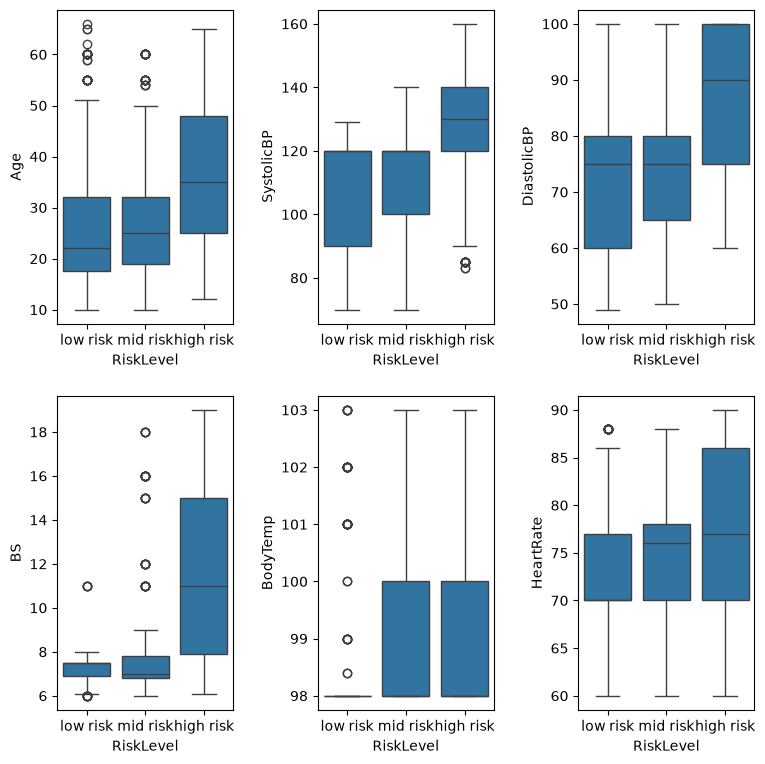

In [24]:
risk_order = ['low risk', 'mid risk', 'high risk']
plt.figure(figsize=(8, 8))  
for index, i in enumerate(numeric_col):
    plt.subplot(2, 3, index+1)        
    sns.boxplot(data = ds , x='RiskLevel' , y = i , order = risk_order)       
    
plt.tight_layout(pad=2)
plt.show()

In [35]:
ds.groupby('RiskLevel')[numeric_col].median().reindex(risk_order)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
RiskLevel,,,,,,
low risk,22.0,120.0,75.0,7.5,98.0,70.0
mid risk,25.0,120.0,75.0,7.0,98.0,76.0
high risk,35.0,130.0,90.0,11.0,98.0,77.0


Age indicates that the High-Risk group falls into an older age bracket (median = 35, compared to 22–25 for the Low and Mid groups); however, the Low and Mid groups overlap significantly, and the High-Risk group also shares some overlap with them—meaning that age alone is not a definitive discriminator but rather reflects a relative association.

HeartRate shows a slight upward trend (medians: Low=70 → Mid=76 → High=77); however, the differences between the medians are small, and there is significant overlap among all three groups—particularly between Mid and High, where the medians are very close (76 vs. 77). Consequently, HeartRate alone is a poor discriminator, especially for distinguishing Mid from High.

Both SystolicBP and DiastolicBP exhibit an increasing trend associated with risk; the medians for the Low and Mid groups are close (showing significant overlap), whereas the High group is relatively distinct and higher—with DiastolicBP showing a slightly more pronounced separation (a 20% increase) compared to SystolicBP (an 8% increase).

BS demonstrates the most distinct and strongest association with High Risk; the median for the High group (11.0) differs markedly from that of the Low/Mid groups (7.0–7.5), with less overlap than observed with other variables.

BodyTemp shows no significant difference between groups (with an identical median of 98.0 across all three); this is likely due to the presence of default values ​​in this column (as identified in Q1) rather than the absence of a genuine association, rendering this variable unreliable for clinical interpretation.